# step1:get the data
## 1.download the data sets from websites(kaggle dataset)
## 2.import all dependance of your project
## 3.load your project

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df = pd.read_excel('pima-data.xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_preg      768 non-null    int64  
 1   glucose_conc  768 non-null    int64  
 2   diastolic_bp  768 non-null    int64  
 3   insulin       768 non-null    int64  
 4   bmi           768 non-null    float64
 5   diab_pred     768 non-null    float64
 6   age           768 non-null    int64  
 7   skin          768 non-null    float64
 8   diabetes      768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


# cleaning the data set

## 1.check the null values is present in your dataset or not

In [4]:
df.isnull()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
763,False,False,False,False,False,False,False,False,False,False,False,False
764,False,False,False,False,False,False,False,False,False,False,False,False
765,False,False,False,False,False,False,False,False,False,False,False,False
766,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

## 2.checking the correlation of your project

In [6]:
df.corr()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898,-0.081672,0.221898,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581,0.057328,0.466581,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068,0.207371,0.065068,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548,0.436783,0.130548,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695,0.392573,0.292695,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844,0.183928,0.173844,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356,-0.113970,0.238356,0.238356
diabetes_orig,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000,0.074752,1.000000,1.000000
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752


In [7]:
def check_corr(size):
    corr=df.corr()
    fig,ax=plt.subplots(figsize=(size,size))
    cmap='rainbow'
    ax.matshow(corr,cmap=cmap)
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.show()

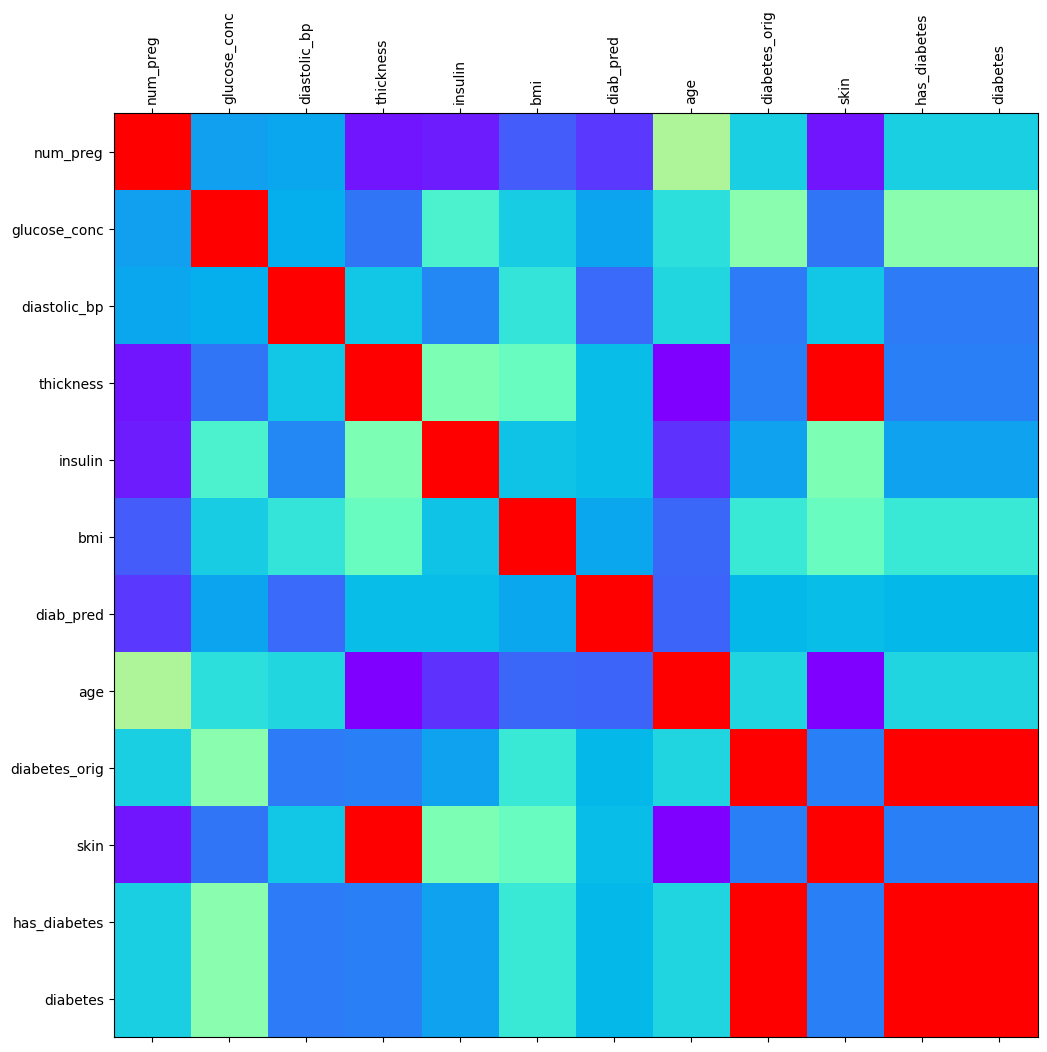

In [8]:
check_corr(12)

## we observed few  columns are coorrelatedto each clumn
## 1.skin and thinkness are correlation each other
## 2.has_diabetes and diabetes_orig	 are correlated each other
## 3.diabetes and diabetes_orig	 are correlated each other
## 4.diabetes and has_diabetes	 are correlated each other

## drop the correlated columns 

In [9]:
df.drop('thickness', axis=1, inplace=True)
df.drop('has_diabetes',axis=1,inplace=True)
df.drop('diabetes_orig',axis=1,inplace=True)

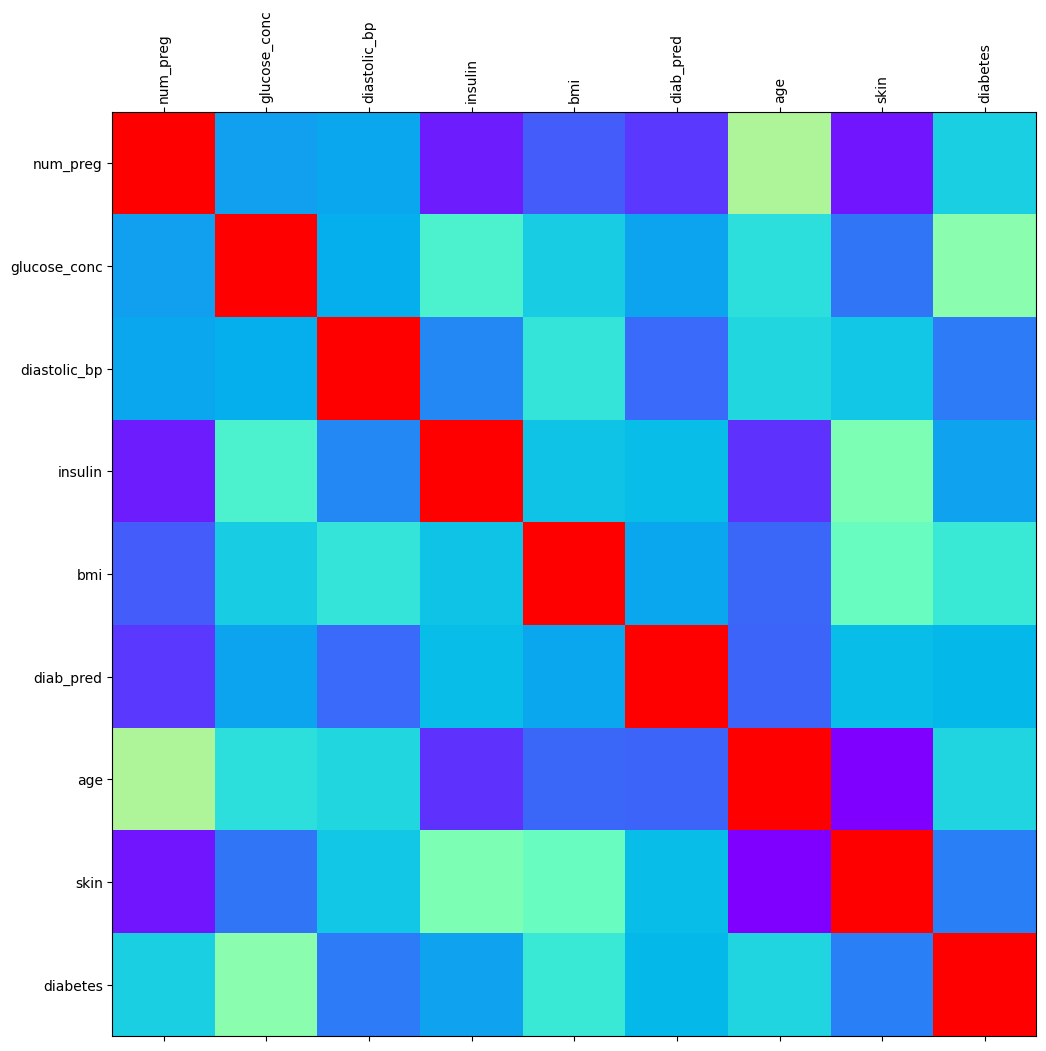

In [10]:
check_corr(12)

## convert string to integer type data

In [11]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,True
1,1,85,66,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,23.3,0.672,32,0.0000,True
3,1,89,66,94,28.1,0.167,21,0.9062,False
4,0,137,40,168,43.1,2.288,33,1.3790,True


In [12]:
df["diabetes"].unique()

array([ True, False])

In [13]:
df['diabetes']=df['diabetes'].map({True:1,False:0})

In [14]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


## 4.check the propertion of data

In [15]:
num_true=len(df.loc[df['diabetes']==1])
num_false=len(df.loc[df['diabetes']==0])
print(num_true)
print(num_false)

268
500


In [16]:
true_percentage=((num_true/(num_true+num_false))*100)
false_percentage=((num_false/(num_true+num_false))*100)

In [17]:
print(true_percentage)
print(false_percentage)

34.89583333333333
65.10416666666666


# step3:train the modal

## 1.train test split

In [18]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='str')

In [22]:
input_columns=['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin', 'bmi', 'diab_pred', 'age', 'diabetes_orig', 'skin']
output_columns=['diabetes']

x=df[input_columns].values
y=df[output_columns].values
x

array([[  6.    , 148.    ,  72.    , ...,  50.    ,   1.    ,   1.379 ],
       [  1.    ,  85.    ,  66.    , ...,  31.    ,   0.    ,   1.1426],
       [  8.    , 183.    ,  64.    , ...,  32.    ,   1.    ,   0.    ],
       ...,
       [  5.    , 121.    ,  72.    , ...,  30.    ,   0.    ,   0.9062],
       [  1.    , 126.    ,  60.    , ...,  47.    ,   1.    ,   0.    ],
       [  1.    ,  93.    ,  70.    , ...,  23.    ,   0.    ,   1.2214]],
      shape=(768, 10))

In [23]:
y


array([[ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [

In [24]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test=train_test_split(x,y,test_size=0.3,random_state=42)
print(x_train)

[[  1.      95.      60.     ...  22.       0.       0.7092]
 [  5.     105.      72.     ...  28.       0.       1.1426]
 [  0.     135.      68.     ...  24.       1.       1.6548]
 ...
 [ 10.     101.      86.     ...  38.       1.       1.4578]
 [  0.     141.       0.     ...  29.       1.       0.    ]
 [  0.     125.      96.     ...  21.       0.       0.    ]]


In [28]:
print(x_test)

[[  6.      98.      58.     ...  43.       0.       1.3002]
 [  2.     112.      75.     ...  21.       0.       1.2608]
 [  2.     108.      64.     ...  21.       0.       0.    ]
 ...
 [  0.     127.      80.     ...  23.       0.       1.4578]
 [  6.     105.      70.     ...  37.       0.       1.2608]
 [  5.      77.      82.     ...  35.       0.       1.6154]]


In [29]:
print(y_test)

[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [ True]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [ True]
 [False]
 [ True]
 [ True]
 [ True]
 [ True]
 [False]
 [ True]
 [ True]
 [ True]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [ True]
 [False]
 [False]
 [ True]
 [ True]
 [ True]
 [False]
 

In [30]:
# d,b,c,a=10,20,30,40
# print(d)
# def m1(x,y):
#     return x+y,x-y,x*y,x/y

# sub1,mull1,div1,sum1=m1(10,20)
# print(sum1)

In [31]:
# x1 = [1,2,3,4,5,6,7,8,9,10]
# y1 =['A','A','A','A','A','B','B','B','B','B']


In [32]:
# x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.3,random_state=42)
# print(x_train)
# print(x_test)
# print(y_train)
# print(y_test)

In [33]:
# [1, 8, 3, 10, 5, 4, 7]
# [9, 2, 6]
# ['A', 'B', 'A', 'B', 'A', 'A', 'B']
# ['B', 'A', 'B']

In [34]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 10)
(231, 10)
(537, 1)
(231, 1)


In [35]:
print('{0:0.2f}% training set'.format((len(x_train)/len(df.index))*100))
print('{0:0.2f}% testing set'.format((len(x_test)/len(df.index))*100))

69.92% training set
30.08% testing set


In [36]:
print('training true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),(len(y_train[y_train[:]==1])/len(y_train)*100)))
print('training true:{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),(len(y_train[y_train[:]==0])/len(y_train)*100)))
print('training true:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==1]),(len(y_test[y_test[:]==1])/len(y_test)*100)))
print('training true:{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==0]),(len(y_test[y_test[:]==0])/len(y_test)*100)))

training true:188 (35.01%)
training true:349 (64.99%)
training true:80 (34.63%)
training true:151 (65.37%)


## plot split preparation

In [37]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'thickness', 'insulin',
       'bmi', 'diab_pred', 'age', 'diabetes_orig', 'skin', 'has_diabetes',
       'diabetes'],
      dtype='str')

In [38]:
total_num_preg=len(df.loc[df['num_preg']==0])
print(f'number of rows missing in num_preg column is {total_num_preg}')

total_glucose_conc=len(df.loc[df['glucose_conc']==0])
print(f'number of rows missing in glucose_conc column is {total_glucose_conc}')
      
total_diastolic_bp=len(df.loc[df['diastolic_bp']==0])
print(f'number of rows missing in diastolic_bp column is {total_diastolic_bp}')

total_insulin=len(df.loc[df['insulin']==0])
print(f'number of rows missing in insulin column is {total_insulin}')

total_bmi=len(df.loc[df['bmi']==0])
print(f'number of rows missing in bmi column is {total_bmi}')

total_diab_pred=len(df.loc[df['diab_pred']==0])
print(f'number of rows missing in diab_pred column is {total_diab_pred}')

total_age=len(df.loc[df['age']==0])
print(f'number of rows missing in age column is {total_age}')

total_skin=len(df.loc[df['skin']==0])
print(f'number of rows missing in skin column is {total_skin}')

total_diabetes=len(df.loc[df['diabetes']==0])
print(f'number of rows missing in diabetes column is {total_diabetes}')

number of rows missing in num_preg column is 111
number of rows missing in glucose_conc column is 5
number of rows missing in diastolic_bp column is 35
number of rows missing in insulin column is 374
number of rows missing in bmi column is 11
number of rows missing in diab_pred column is 0
number of rows missing in age column is 0
number of rows missing in skin column is 227
number of rows missing in diabetes column is 500


In [39]:
from sklearn.impute import SimpleImputer

In [40]:
fill_zeros=SimpleImputer(missing_values=0,strategy='mean')
x_train=fill_zeros.fit_transform(x_train)
x_test=fill_zeros.fit_transform(x_test)

In [41]:
x_train[0:5]

array([[1.00000000e+00, 9.50000000e+01, 6.00000000e+01, 1.80000000e+01,
        5.80000000e+01, 2.39000000e+01, 2.60000000e-01, 2.20000000e+01,
        1.00000000e+00, 7.09200000e-01],
       [5.00000000e+00, 1.05000000e+02, 7.20000000e+01, 2.90000000e+01,
        3.25000000e+02, 3.69000000e+01, 1.59000000e-01, 2.80000000e+01,
        1.00000000e+00, 1.14260000e+00],
       [4.34056399e+00, 1.35000000e+02, 6.80000000e+01, 4.20000000e+01,
        2.50000000e+02, 4.23000000e+01, 3.65000000e-01, 2.40000000e+01,
        1.00000000e+00, 1.65480000e+00],
       [4.00000000e+00, 1.31000000e+02, 6.80000000e+01, 2.10000000e+01,
        1.66000000e+02, 3.31000000e+01, 1.60000000e-01, 2.80000000e+01,
        1.00000000e+00, 8.27400000e-01],
       [1.00000000e+00, 1.03000000e+02, 3.00000000e+01, 3.80000000e+01,
        8.30000000e+01, 4.33000000e+01, 1.83000000e-01, 3.30000000e+01,
        1.00000000e+00, 1.49720000e+00]])

## e.standardize the data

# : it is a dataprocessing technique which is used to make all values into single scale i.e mean is o and sd nis 1

In [42]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [43]:
x_train[0:5]

array([[-1.15687814e+00, -8.96200501e-01, -1.00392807e+00,
        -1.25782829e+00, -1.14563966e+00, -1.20379368e+00,
        -6.14216360e-01, -9.48610283e-01,  0.00000000e+00,
        -1.25782829e+00],
       [ 2.28370750e-01, -5.64089421e-01, -1.97904130e-02,
         4.16397301e-02,  1.99702256e+00,  6.64529988e-01,
        -9.09737865e-01, -4.34666726e-01,  0.00000000e+00,
         4.16397301e-02],
       [ 6.15174086e-16,  4.32243819e-01, -3.47836300e-01,
         1.57737467e+00,  1.11425228e+00,  1.44060290e+00,
        -3.06991033e-01, -7.77295764e-01,  0.00000000e+00,
         1.57737467e+00],
       [-1.17941473e-01,  2.99399387e-01, -3.47836300e-01,
        -9.03427923e-01,  1.25549552e-01,  1.18404607e-01,
        -9.06811910e-01, -4.34666726e-01,  0.00000000e+00,
        -9.03427923e-01],
       [-1.15687814e+00, -6.30511637e-01, -3.46427222e+00,
         1.10484084e+00, -8.51382901e-01,  1.58432010e+00,
        -8.39514933e-01, -6.38042901e-03,  0.00000000e+00,
         1.

## train the model using navibayees alogrithm

In [44]:
from sklearn.naive_bayes import GaussianNB

In [45]:
nb_model=GaussianNB()
nb_model.fit(x_train,y_train.ravel())

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[349.,188.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[bool](2,)","[False, True]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 10)","[[-0.16,-0.38,-0.13,...,-0.21, 0. ,-0.16], [ 0.31, 0.7 , 0.24,..., 0.38, 0. , 0.29]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 10)","[[0.86,0.61,0.97,...,0.94,0. ,1.01], [1.12,0.96,0.98,...,0.89,0. ,0.85]]"


In [46]:
# nb_predict_model=nb_model.predict(x_test)


In [47]:
from sklearn import metrics
nb_predict_train=nb_model.predict(x_train)
print(f"predicted accuracy of naive bayees modelis {metrics.accuracy_score(y_train,nb_predict_train)}")



predicted accuracy of naive bayees modelis 0.7541899441340782


In [48]:

nb_predict_test=nb_model.predict(x_test)
print(f"predicted accuracy of nai vebayees modelis {metrics.accuracy_score(y_test,nb_predict_test)}")



predicted accuracy of nai vebayees modelis 0.7229437229437229


## step4: testing using confusion matrix

In [49]:
print("confusion matrix")
print("{}".format(metrics.confusion_matrix(y_test,nb_predict_test)))

confusion matrix
[[116  35]
 [ 29  51]]


## classfication report

In [50]:
print("classification report")
print("{}".format(metrics.classification_report(y_test,nb_predict_test)))

classification report
              precision    recall  f1-score   support

       False       0.80      0.77      0.78       151
        True       0.59      0.64      0.61        80

    accuracy                           0.72       231
   macro avg       0.70      0.70      0.70       231
weighted avg       0.73      0.72      0.73       231



In [51]:
from sklearn.metrics import classification_report
y_pred=[True,True,False,True,False,
        False,True,True,False,True]
y_true=[False,True,False,True,True,
        False,False,True,False,True]
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

       False       0.75      0.60      0.67         5
        True       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



## train the model using random forest 

In [52]:
from sklearn.ensemble import RandomForestClassifier


In [53]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train.ravel())

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [54]:
from sklearn import metrics
nb_predict_train=rf_model.predict(x_train)
print(f"predicted accuracy of random forest model is {metrics.accuracy_score(y_train,nb_predict_train)}")

predicted accuracy of random forest model is 1.0


In [55]:
rf_predict_test=rf_model.predict(x_test)
print(f"predicted accuracy of random forest modelis {metrics.accuracy_score(y_test,rf_predict_test)}")

predicted accuracy of random forest modelis 0.7402597402597403


In [56]:
print("confusion matrix")
print("{}".format(metrics.confusion_matrix(y_test,rf_predict_test)))

confusion matrix
[[121  30]
 [ 30  50]]


In [57]:
print("classification report")
print("{}".format(metrics.classification_report(y_test,rf_predict_test)))

classification report
              precision    recall  f1-score   support

       False       0.80      0.80      0.80       151
        True       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



## train the model USIN KNN

In [58]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
kn_model = RandomForestClassifier(random_state=42)
kn_model.fit(x_train,y_train.ravel())

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [60]:
from sklearn import metrics
kn_predict_train=kn_model.predict(x_train)
print(f"predicted accuracy of random forest model is {metrics.accuracy_score(y_train,kn_predict_train)}")

predicted accuracy of random forest model is 1.0


In [61]:
kn_predict_test=kn_model.predict(x_test)
print(f"predicted accuracy of random forest modelis {metrics.accuracy_score(y_test,kn_predict_test)}")

predicted accuracy of random forest modelis 0.7402597402597403


In [62]:
print("confusion matrix")
print("{}".format(metrics.confusion_matrix(y_test,kn_predict_test)))

confusion matrix
[[121  30]
 [ 30  50]]


In [63]:
print("classification report")
print("{}".format(metrics.classification_report(y_test,kn_predict_test)))

classification report
              precision    recall  f1-score   support

       False       0.80      0.80      0.80       151
        True       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



## conclusion: After high analysis i will random forest alogithem for my model
## algorithem for my model

## which is giving 75% accuracy